In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import os
from datetime import datetime
from openpyxl import load_workbook, Workbook
import pandas as pd
import random

ModuleNotFoundError: No module named 'tensorflow'

In [22]:
LOG_FILE = "../logs/NN_Class_logbook.xlsx"

def log_experiment(
        experiment,
        history,
        hidden_layers,
        hidden_nodes,
        dropout_rate,
        epochs,
        learning_rate,
        batch_size=32,
        notes=""
    ):

    history = history.history

    row = {
        "Experiment": experiment,
        "Date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "Hidden Layers": hidden_layers,
        "Hidden Nodes": hidden_nodes,
        "Dropout Rate": dropout_rate,
        "Epochs": epochs,
        "Learning Rate": learning_rate,
        "Batch Size": batch_size,

        "Train Accuracy": history["accuracy"][-1],
        "Validation Accuracy": history["val_accuracy"][-1],
        "Train Loss": history["loss"][-1],
        "Validation Loss": history["val_loss"][-1],
        "Gap Accuracy": history["accuracy"][-1] - history["val_accuracy"][-1],

        "Notes": notes
    }

    df_row = pd.DataFrame([row])

    # Make sure the logs folder exists
    os.makedirs(os.path.dirname(LOG_FILE), exist_ok=True)

    # If file exists, read old log and add new row
    if os.path.exists(LOG_FILE):
        df_existing = pd.read_excel(LOG_FILE)
        df_log = pd.concat([df_existing, df_row], ignore_index=True)
    else:
        df_log = df_row

    # Save full updated logbook
    df_log.to_excel(LOG_FILE, index=False)

    print(f"Experiment '{experiment}' logged successfully.")
    print(f"Val accuracy: {history['val_accuracy'][-1]:.4f}, Val loss: {history['val_loss'][-1]:.4f}")

In [23]:
(train_data, train_labels), (test_data, test_labels) = fashion_mnist.load_data()

In [24]:
print("My train data Shape:", train_data.shape)
print("My train labels :", train_labels.shape)
print("Maximum label : ", train_labels.max())

My train data Shape: (60000, 28, 28)
My train labels : (60000,)
Maximum label :  9


Class names :  ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


Text(0.5, 1.0, 'Bag')

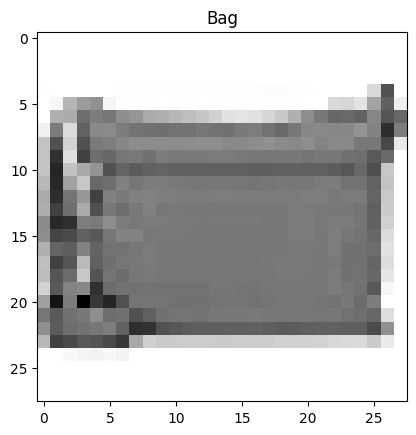

In [25]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
print("Class names : ", class_names)
index_of_choice = random.randint(0, len(train_data))

plt.imshow(train_data[index_of_choice],cmap=plt.cm.binary)
plt.title(class_names[train_labels[index_of_choice]])

In [26]:
#first model unnormalized data

#create a model - layers, neurons, activations, input shape, output shape
model_1 = tf.keras.Sequential([
    #input layer
    tf.keras.layers.Flatten(input_shape=train_data[0].shape),
    #hidden layers
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    #output layer
    tf.keras.layers.Dense(10, activation=tf.keras.activations.softmax)
])

#compile the model - The loss function calculates error, 
#and the optimizer updates the weights using the learning rate.
model_1.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(0.001),
                metrics=["accuracy"])

# fit the model - pass data - epoch = itierations 
history_1 = model_1.fit(train_data, train_labels, epochs=10, validation_data=(test_data, test_labels))

log_experiment(
    experiment="Ex.1 - Unnormalized data",
    history=history_1,
    hidden_layers=2,
    hidden_nodes=4,
    dropout_rate=None,
    epochs=10,
    learning_rate=0.001,
    notes="First model with unnormalized data."
)


Epoch 1/10


c:\Users\tenbe\Desktop\DEAI_Portfolio\.venv313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.0978 - loss: 2.5042 - val_accuracy: 0.1000 - val_loss: 2.3039
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.0963 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3033
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.0979 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3033
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.0986 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3033
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.0960 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3033
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.0989 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3033
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.0993 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3033
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.0992 - loss: 2.3028 - val_accurac

In [27]:
# model 2 normalized data

train_data_norm = train_data / train_data.max()
test_data_norm = test_data / test_data.max()

#modern achitecture
model_2 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    
    tf.keras.layers.Dense(10, activation="softmax")
])

model_2.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(0.001),
                metrics=["accuracy"])

history_2 = model_2.fit(train_data_norm, train_labels, epochs=10, validation_data=(test_data_norm, test_labels))

log_experiment(
    experiment="Ex.2 - Normalized data",
    history=history_2,
    hidden_layers=2,
    hidden_nodes=4,
    dropout_rate=None,
    epochs=10,
    learning_rate=0.001,
    notes="Second model with normalized data."
)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.4746 - loss: 1.2930 - val_accuracy: 0.5890 - val_loss: 0.9645
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6905 - loss: 0.8205 - val_accuracy: 0.7339 - val_loss: 0.7660
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7463 - loss: 0.7176 - val_accuracy: 0.7609 - val_loss: 0.6908
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7691 - loss: 0.6569 - val_accuracy: 0.7705 - val_loss: 0.6492
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7767 - loss: 0.6294 - val_accuracy: 0.7735 - val_loss: 0.6341
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7825 - loss: 0.6145 - val_accuracy: 0.7797 - val_loss: 0.6251
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7876 - loss: 0.6025 - val_accuracy: 0.7764 - val_loss: 0.6207
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7900 - loss: 0.5942 - 

In [28]:
# model 3 normalized data and more hidden layers and more neurons

train_data_norm = train_data / train_data.max()
test_data_norm = test_data / test_data.max()

model_3 = tf.keras.Sequential([
    
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    
    tf.keras.layers.Dense(10, activation="softmax")
])

model_3.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(0.001),
                metrics=["accuracy"])

history_3 = model_3.fit(train_data_norm, train_labels, epochs=10, validation_data=(test_data_norm, test_labels))

log_experiment(
    experiment="Ex.3 - Normalized data ++",
    history=history_3,
    hidden_layers=4,
    hidden_nodes="128, 64, 32, 16",
    dropout_rate=None,
    epochs=10,
    learning_rate=0.001,
    notes="Third model with normalized data, more hidden layers and more neurons."
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8071 - loss: 0.5395 - val_accuracy: 0.8437 - val_loss: 0.4283
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8625 - loss: 0.3789 - val_accuracy: 0.8530 - val_loss: 0.4128
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8732 - loss: 0.3454 - val_accuracy: 0.8696 - val_loss: 0.3720
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8807 - loss: 0.3212 - val_accuracy: 0.8703 - val_loss: 0.3745
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8881 - loss: 0.3032 - val_accuracy: 0.8762 - val_loss: 0.3580
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8936 - loss: 0.2882 - val_accuracy: 0.8778 - val_loss: 0.3399
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8964 - loss: 0.2789 - val_accuracy: 0.8710 - val_loss: 0.3603
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9006 - loss: 0.2672 - 

In [29]:
# model 4 normalized data and more hidden layers and more neurons and dropout
# dropout is a regularization technique that randomly sets a fraction of input units to 0 at each update during training time, which helps prevent overfitting.
train_data_norm = train_data / train_data.max()
test_data_norm = test_data / test_data.max()

model_4 = tf.keras.Sequential([
    
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    
    tf.keras.layers.Dense(10, activation="softmax")
])

model_4.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(0.001),
                metrics=["accuracy"])

history_4 = model_4.fit(train_data_norm, train_labels, epochs=10, validation_data=(test_data_norm, test_labels))

log_experiment(
    experiment="Ex.4 - Normalized data +++",
    history=history_4,
    hidden_layers=4,
    hidden_nodes="128, 64, 32, 16",
    dropout_rate=0.2,
    epochs=10,
    learning_rate=0.001,
    notes="Fourth model with normalized data, more hidden layers and more neurons and dropout."
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7037 - loss: 0.8490 - val_accuracy: 0.8182 - val_loss: 0.5163
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8112 - loss: 0.5569 - val_accuracy: 0.8341 - val_loss: 0.4707
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8263 - loss: 0.5103 - val_accuracy: 0.8386 - val_loss: 0.4427
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8412 - loss: 0.4720 - val_accuracy: 0.8570 - val_loss: 0.4061
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8452 - loss: 0.4547 - val_accuracy: 0.8598 - val_loss: 0.3912
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8510 - loss: 0.4416 - val_accuracy: 0.8621 - val_loss: 0.4181
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8540 - loss: 0.4283 - val_accuracy: 0.8599 - val_loss: 0.4020
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8563 - loss: 0.4199 - 

In [33]:
#model 5 most successful model with more epochs

train_data_norm = train_data / train_data.max()
test_data_norm = test_data / test_data.max()

model_5 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    
    tf.keras.layers.Dense(10, activation="softmax")
])

model_5.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(0.001),
                metrics=["accuracy"])
history_5 = model_5.fit(train_data_norm, train_labels, epochs=20, validation_data=(test_data_norm, test_labels))

log_experiment(
    experiment="Ex.5 - Norm, Epoch++",
    history=history_5,
    hidden_layers=4,
    hidden_nodes="128, 64, 32, 16",
    dropout_rate=None,
    epochs=20,
    learning_rate=0.001,
    notes="Fifth model with normalized data and more epochs."
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8022 - loss: 0.5547 - val_accuracy: 0.8467 - val_loss: 0.4296
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8622 - loss: 0.3771 - val_accuracy: 0.8484 - val_loss: 0.4171
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8760 - loss: 0.3367 - val_accuracy: 0.8731 - val_loss: 0.3526
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8836 - loss: 0.3152 - val_accuracy: 0.8743 - val_loss: 0.3467
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8903 - loss: 0.2989 - val_accuracy: 0.8702 - val_loss: 0.3639
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8951 - loss: 0.2830 - val_accuracy: 0.8686 - val_loss: 0.3804
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8971 - loss: 0.2760 - val_accuracy: 0.8769 - val_loss: 0.3511
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9023 - loss: 0.2627 - 

In [34]:
#model 6 most successful model with more epochs and dropout

train_data_norm = train_data / train_data.max()
test_data_norm = test_data / test_data.max()

model_6 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    
    tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dropout(0.2),
    
    tf.keras.layers.Dense(10, activation="softmax")
])

model_6.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(0.001),
                metrics=["accuracy"])
history_6 = model_6.fit(train_data_norm, train_labels, epochs=20, validation_data=(test_data_norm, test_labels))

log_experiment(
    experiment="Ex.6 - Norm, Epoch++",
    history=history_6,
    hidden_layers=4,
    hidden_nodes="128, 64, 32, 16",
    dropout_rate=0.2,
    epochs=20,
    learning_rate=0.001,
    notes="Sixth model with more epochs and dropout."
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.6933 - loss: 0.8344 - val_accuracy: 0.8137 - val_loss: 0.5111
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8062 - loss: 0.5668 - val_accuracy: 0.8400 - val_loss: 0.4507
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8277 - loss: 0.5092 - val_accuracy: 0.8522 - val_loss: 0.4260
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8407 - loss: 0.4754 - val_accuracy: 0.8575 - val_loss: 0.4017
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8475 - loss: 0.4524 - val_accuracy: 0.8495 - val_loss: 0.4132
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8510 - loss: 0.4416 - val_accuracy: 0.8652 - val_loss: 0.3818
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8569 - loss: 0.4224 - val_accuracy: 0.8594 - val_loss: 0.3926
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8596 - loss: 0.4145 - 

In [36]:
#model 7, faster learning, more epochs

train_data_norm = train_data / train_data.max()
test_data_norm = test_data / test_data.max()

model_7 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    
    tf.keras.layers.Dense(10, activation="softmax")
])

model_7.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(0.01),
                metrics=["accuracy"])

history_7 = model_7.fit(train_data_norm, train_labels, epochs=20, validation_data=(test_data_norm, test_labels))

log_experiment(
    experiment="Ex.7 - Norm, Epoch++, LR++",
    history=history_7,
    hidden_layers=4,
    hidden_nodes="128, 64, 32, 16",
    dropout_rate=None,
    epochs=20,
    learning_rate=0.01,
    notes="Seventh model with more epochs and faster learning rate."
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.7881 - loss: 0.5914 - val_accuracy: 0.8185 - val_loss: 0.5159
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8347 - loss: 0.4701 - val_accuracy: 0.8138 - val_loss: 0.5247
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8424 - loss: 0.4491 - val_accuracy: 0.8320 - val_loss: 0.4789
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8484 - loss: 0.4313 - val_accuracy: 0.8285 - val_loss: 0.4965
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8504 - loss: 0.4237 - val_accuracy: 0.8439 - val_loss: 0.4500
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8516 - loss: 0.4288 - val_accuracy: 0.8424 - val_loss: 0.4421
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8551 - loss: 0.4160 - val_accuracy: 0.8242 - val_loss: 0.4979
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8558 - loss: 0.4162

In [38]:
#model 8, faster learning, more epochs, and dropout

train_data_norm = train_data / train_data.max()
test_data_norm = test_data / test_data.max()

model_8 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    
    tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dropout(0.2),
    
    tf.keras.layers.Dense(10, activation="softmax")
])

model_8.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(0.01),
                metrics=["accuracy"])

history_8 = model_8.fit(train_data_norm, train_labels, epochs=20, validation_data=(test_data_norm, test_labels))

log_experiment(
    experiment="Ex.8 - Norm, Epoch++, LR++",
    history=history_8,
    hidden_layers=4,
    hidden_nodes="128, 64, 32, 16",
    dropout_rate=0.2,
    epochs=20,
    learning_rate=0.01,
    notes="Eighth model with more epochs and faster learning rate and dropout."
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.6235 - loss: 0.9658 - val_accuracy: 0.7142 - val_loss: 0.7132
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.6758 - loss: 0.8509 - val_accuracy: 0.7504 - val_loss: 0.6683
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6869 - loss: 0.8422 - val_accuracy: 0.7738 - val_loss: 0.6102
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.6906 - loss: 0.8283 - val_accuracy: 0.7627 - val_loss: 0.6370
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6885 - loss: 0.8415 - val_accuracy: 0.7564 - val_loss: 0.6547
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.6909 - loss: 0.8528 - val_accuracy: 0.7559 - val_loss: 0.6668
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.6859 - loss: 0.8686 - val_accuracy: 0.7267 - val_loss: 0.6650
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.6690 - loss: 0.9

In [41]:
#model 9, most succesful model, learn--, epoch++

train_data_norm = train_data / train_data.max()
test_data_norm = test_data / test_data.max()

model_9 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    
    tf.keras.layers.Dense(10, activation="softmax")
])

model_9.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(0.0001),
                metrics=["accuracy"])

history_9 = model_9.fit(train_data_norm, train_labels, epochs=20, validation_data=(test_data_norm, test_labels))

log_experiment(
    experiment="Ex.9 - Norm, Epoch++",
    history=history_9,
    hidden_layers=4,
    hidden_nodes="128, 64, 32, 16",
    dropout_rate=None,
    epochs=20,
    learning_rate=0.0001,
    notes="Ninth model with more epochs and slower learning rate."
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.7059 - loss: 0.8668 - val_accuracy: 0.8099 - val_loss: 0.5537
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8350 - loss: 0.4840 - val_accuracy: 0.8319 - val_loss: 0.4916
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8498 - loss: 0.4339 - val_accuracy: 0.8359 - val_loss: 0.4664
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8578 - loss: 0.4060 - val_accuracy: 0.8472 - val_loss: 0.4332
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8643 - loss: 0.3872 - val_accuracy: 0.8486 - val_loss: 0.4313
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8685 - loss: 0.3700 - val_accuracy: 0.8523 - val_loss: 0.4272
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8742 - loss: 0.3570 - val_accuracy: 0.8582 - val_loss: 0.4030
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8774 - loss: 0.3455

In [42]:
from tensorflow.keras import regularizers, callbacks

# Experiment 10: "ideal" model

model_10 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.30),

    tf.keras.layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.20),

    tf.keras.layers.Dense(10, activation="softmax")
])

learning_rate = 5e-4
model_10.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate),
    metrics=["accuracy"]
)

es = callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
rlr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)

history_10 = model_10.fit(
    train_data_norm, train_labels,
    epochs=30,
    batch_size=64,
    validation_data=(test_data_norm, test_labels),
    callbacks=[es, rlr],
    verbose=2
)

log_experiment(
    experiment="Ex.10 - Ideal model (BN + Dropout + L2 + LR scheduler)",
    history=history_10,
    hidden_layers=3,
    hidden_nodes="256, 128, 64",
    dropout_rate=0.30,
    epochs=len(history_10.history["loss"]),
    learning_rate=learning_rate,
    batch_size=64,
    notes="BatchNorm + Dropout + L2 regularization + ReduceLROnPlateau + EarlyStopping"
)

Epoch 1/30
938/938 - 12s - 13ms/step - accuracy: 0.7721 - loss: 0.7218 - val_accuracy: 0.8370 - val_loss: 0.5225 - learning_rate: 5.0000e-04
Epoch 2/30
938/938 - 8s - 9ms/step - accuracy: 0.8302 - loss: 0.5434 - val_accuracy: 0.8415 - val_loss: 0.4988 - learning_rate: 5.0000e-04
Epoch 3/30
938/938 - 9s - 10ms/step - accuracy: 0.8410 - loss: 0.5059 - val_accuracy: 0.8468 - val_loss: 0.4780 - learning_rate: 5.0000e-04
Epoch 4/30
938/938 - 8s - 8ms/step - accuracy: 0.8510 - loss: 0.4758 - val_accuracy: 0.8583 - val_loss: 0.4531 - learning_rate: 5.0000e-04
Epoch 5/30
938/938 - 8s - 8ms/step - accuracy: 0.8565 - loss: 0.4588 - val_accuracy: 0.8666 - val_loss: 0.4257 - learning_rate: 5.0000e-04
Epoch 6/30
938/938 - 8s - 8ms/step - accuracy: 0.8602 - loss: 0.4487 - val_accuracy: 0.8582 - val_loss: 0.4429 - learning_rate: 5.0000e-04
Epoch 7/30
938/938 - 8s - 8ms/step - accuracy: 0.8621 - loss: 0.4331 - val_accuracy: 0.8629 - val_loss: 0.4326 - learning_rate: 5.0000e-04
Epoch 8/30
938/938 - 8s 

In [ ]:
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(
        test_labels, 
        model_4.predict(test_data_norm).argmax(axis=1)), 
        display_labels=class_names
).plot(cmap=plt.cm.Blues)
plt.xticks(rotation=45)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


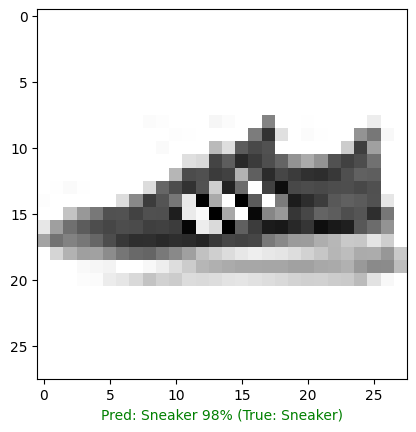

In [37]:
def plot_random_image(model, images, true_labels, classes):
    #select random index, get the image and true label
    i = random.randrange(len(images))
    image_to_predict = images[i]
    true_label_name = classes[true_labels[i]]

    #turn image into batch of one and predict then get the predicted label
    pred_probs = model.predict(tf.expand_dims(image_to_predict, axis=0))
    predicted_label_name = classes[pred_probs.argmax()]

    #display image with findings, greed good red bad 
    plt.imshow(image_to_predict, cmap=plt.cm.binary)

    if predicted_label_name == true_label_name:
        color = "green"
    else:
        color = "red"
    #percentage is basically how confident the model is about its prediction
    plt.xlabel(
        "Pred: {} {:2.0f}% (True: {})".format(
            predicted_label_name,
            100 * tf.reduce_max(pred_probs),
            true_label_name
        ),
        color=color
    )
  
plot_random_image(model_4,test_data_norm,test_labels,class_names)